In [1]:
# If running on Kaggle, most of these are already available.
# Keep this cell simple and safe.

import os
import re
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)
print("Seed set successfully.")

Seed set successfully.


In [3]:
# Update path if your file is in another Kaggle input folder
DATA_PATH = "/kaggle/input/datasets/himani2705/multiple/labeled_data.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [4]:
print("Columns:\n", df.columns.tolist())
print("\nInfo:\n")
print(df.info())

print("\nNull values:\n", df.isnull().sum())

Columns:
 ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None

Null values:
 Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64


Class distribution:

class
0     1430
1    19190
2     4163
Name: count, dtype: int64


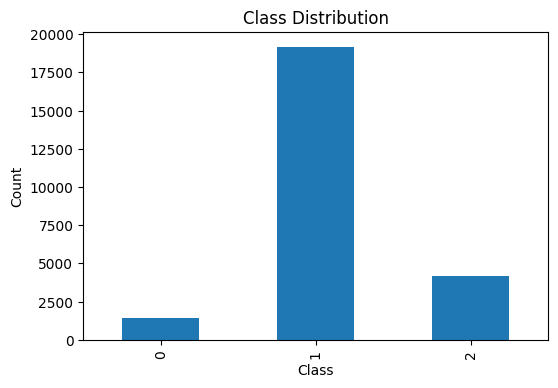

In [5]:
print("Class distribution:\n")
print(df["class"].value_counts().sort_index())

plt.figure(figsize=(6,4))
df["class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Class distribution:

class
0     1430
1    19190
2     4163
Name: count, dtype: int64


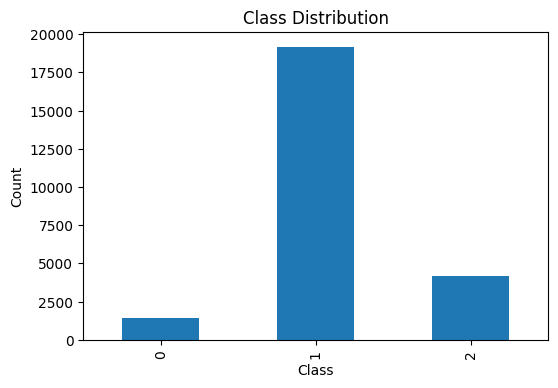

In [6]:
print("Class distribution:\n")
print(df["class"].value_counts().sort_index())

plt.figure(figsize=(6,4))
df["class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [7]:
columns_to_drop = ["Unnamed: 0", "count", "hate_speech", "offensive_language", "neither"]

existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print("Remaining columns:", df.columns.tolist())
df.head()

Remaining columns: ['class', 'tweet']


,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [8]:
df = df.rename(columns={"tweet": "text", "class": "label"})
df.head()

,label,text
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [9]:
print("Before cleaning:", df.shape)

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str).str.strip()

# Remove empty texts
df = df[df["text"] != ""].copy()

# Remove exact duplicates
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("After cleaning:", df.shape)
df.head()

Before cleaning: (24783, 2)
After cleaning: (24783, 2)


,label,text
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [10]:
def light_clean_text(text: str) -> str:
    text = str(text)
    
    # Replace URLs
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    
    # Replace user mentions
    text = re.sub(r"@\w+", " USER ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["text"] = df["text"].apply(light_clean_text)
df.head()

,label,text
0,2,!!! RT USER : As a woman you shouldn't complai...
1,1,!!!!! RT USER : boy dats cold...tyga dwn bad f...
2,1,!!!!!!! RT USER Dawg!!!! RT USER : You ever fu...
3,1,!!!!!!!!! RT USER : USER she look like a tranny
4,1,!!!!!!!!!!!!! RT USER : The shit you hear abou...


In [11]:
df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))
df["upper_ratio"] = df["text"].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
df["exclamation_count"] = df["text"].apply(lambda x: x.count("!"))
df["question_count"] = df["text"].apply(lambda x: x.count("?"))

df.head()

,label,text,char_len,word_len,upper_ratio,exclamation_count,question_count
0,2,!!! RT USER : As a woman you shouldn't complai...,132,26,0.053030,3,0
1,1,!!!!! RT USER : boy dats cold...tyga dwn bad f...,82,17,0.073171,7,0
2,1,!!!!!!! RT USER Dawg!!!! RT USER : You ever fu...,102,22,0.147059,11,1
3,1,!!!!!!!!! RT USER : USER she look like a tranny,47,10,0.212766,9,0
4,1,!!!!!!!!!!!!! RT USER : The shit you hear abou...,127,27,0.055118,13,0


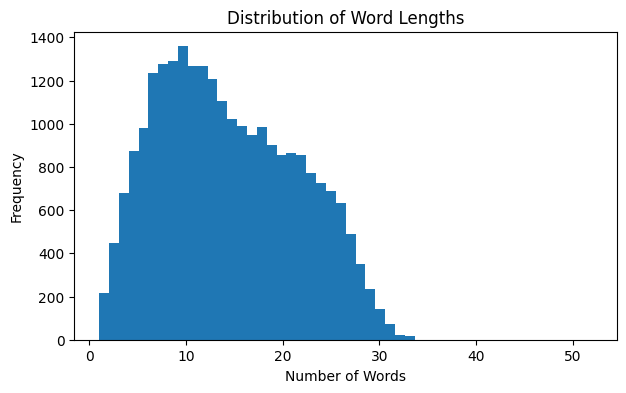

count    24783.000000
mean        14.605859
std          7.026857
min          1.000000
25%          9.000000
50%         14.000000
75%         20.000000
max         52.000000
Name: word_len, dtype: float64


In [12]:
plt.figure(figsize=(7,4))
plt.hist(df["word_len"], bins=50)
plt.title("Distribution of Word Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print(df["word_len"].describe())

In [13]:
for col in ["char_len", "word_len", "upper_ratio", "exclamation_count", "question_count"]:
    print(f"\n--- {col} by label ---")
    print(df.groupby("label")[col].mean())


--- char_len by label ---
label
0    75.471329
1    75.666076
2    84.016094
Name: char_len, dtype: float64

--- word_len by label ---
label
0    14.253147
1    14.469620
2    15.355032
Name: word_len, dtype: float64

--- upper_ratio by label ---
label
0    0.110195
1    0.092384
2    0.114267
Name: upper_ratio, dtype: float64

--- exclamation_count by label ---
label
0    0.176923
1    0.170297
2    0.201057
Name: exclamation_count, dtype: float64

--- question_count by label ---
label
0    0.122378
1    0.098332
2    0.123709
Name: question_count, dtype: float64


In [14]:
label_map = {
    0: "hate_speech",
    1: "offensive_language",
    2: "neither"
}

df["label_name"] = df["label"].map(label_map)
df[["text", "label", "label_name"]].head()

,text,label,label_name
0,!!! RT USER : As a woman you shouldn't complai...,2,neither
1,!!!!! RT USER : boy dats cold...tyga dwn bad f...,1,offensive_language
2,!!!!!!! RT USER Dawg!!!! RT USER : You ever fu...,1,offensive_language
3,!!!!!!!!! RT USER : USER she look like a tranny,1,offensive_language
4,!!!!!!!!!!!!! RT USER : The shit you hear abou...,1,offensive_language


In [15]:
train_df, val_df = train_test_split(
    df[["text", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

print("\nTrain class distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

print("\nVal class distribution:")
print(val_df["label"].value_counts(normalize=True).sort_index())

Train shape: (19826, 2)
Val shape: (4957, 2)

Train class distribution:
label
0    0.057702
1    0.774337
2    0.167961
Name: proportion, dtype: float64

Val class distribution:
label
0    0.057696
1    0.774259
2    0.168045
Name: proportion, dtype: float64


In [16]:
classes = np.array(sorted(train_df["label"].unique()))
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights_dict = {int(cls): float(wt) for cls, wt in zip(classes, class_weights)}
print("Class weights:", class_weights_dict)

Class weights: {0: 5.776806526806527, 1: 0.4304759423310752, 2: 1.9845845845845846}


In [17]:
train_df.to_csv("train_processed.csv", index=False)
val_df.to_csv("val_processed.csv", index=False)

print("Saved:")
print("- train_processed.csv")
print("- val_processed.csv")

Saved:
- train_processed.csv
- val_processed.csv


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [23]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model"):
    # Train
    model.fit(X_train, y_train)

    # Predict
    val_preds = model.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, val_preds)
    macro_f1 = f1_score(y_val, val_preds, average="macro")
    weighted_f1 = f1_score(y_val, val_preds, average="weighted")

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_val, val_preds, target_names=["hate_speech", "offensive_language", "neither"]))

    # Confusion Matrix
    cm = confusion_matrix(y_val, val_preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["hate_speech", "offensive_language", "neither"]
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "model_name": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "preds": val_preds
    }

In [25]:
X_train = train_df["text"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label"].tolist()

print("Train samples:", len(X_train))
print("Val samples  :", len(X_val))

Train samples: 19826
Val samples  : 4957



TF-IDF + Logistic Regression
Accuracy     : 0.8963
Macro F1     : 0.7406
Weighted F1  : 0.8942

Classification Report:

                    precision    recall  f1-score   support

       hate_speech       0.48      0.39      0.43       286
offensive_language       0.94      0.94      0.94      3838
           neither       0.82      0.89      0.85       833

          accuracy                           0.90      4957
         macro avg       0.75      0.74      0.74      4957
      weighted avg       0.89      0.90      0.89      4957



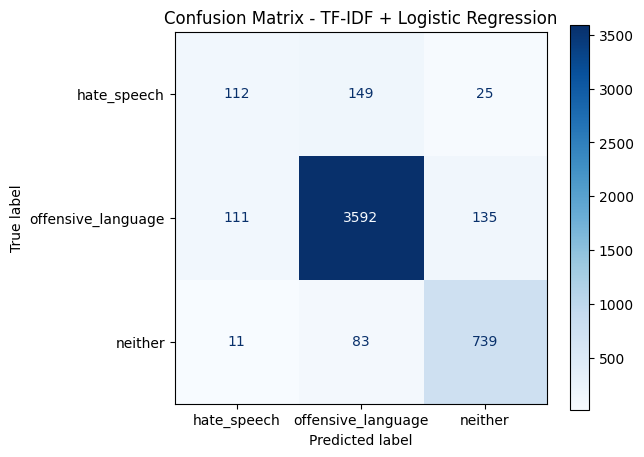

In [26]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words=None,
        ngram_range=(1, 2),
        min_df=2,
        max_features=100000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        C=4.0,
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=42
    ))
])

lr_results = evaluate_model(
    lr_pipeline,
    X_train, y_train,
    X_val, y_val,
    model_name="TF-IDF + Logistic Regression"
)


TF-IDF + Linear SVM
Accuracy     : 0.8953
Macro F1     : 0.7343
Weighted F1  : 0.8929

Classification Report:

                    precision    recall  f1-score   support

       hate_speech       0.46      0.37      0.41       286
offensive_language       0.94      0.94      0.94      3838
           neither       0.83      0.88      0.86       833

          accuracy                           0.90      4957
         macro avg       0.74      0.73      0.73      4957
      weighted avg       0.89      0.90      0.89      4957



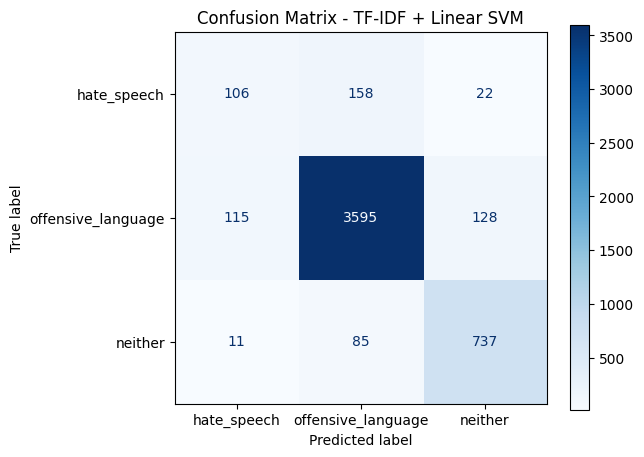

In [27]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words=None,
        ngram_range=(1, 2),
        min_df=2,
        max_features=100000,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

svm_results = evaluate_model(
    svm_pipeline,
    X_train, y_train,
    X_val, y_val,
    model_name="TF-IDF + Linear SVM"
)


Char TF-IDF + Linear SVM
Accuracy     : 0.8878
Macro F1     : 0.7255
Weighted F1  : 0.8874

Classification Report:

                    precision    recall  f1-score   support

       hate_speech       0.41      0.38      0.40       286
offensive_language       0.94      0.93      0.93      3838
           neither       0.81      0.88      0.84       833

          accuracy                           0.89      4957
         macro avg       0.72      0.73      0.73      4957
      weighted avg       0.89      0.89      0.89      4957



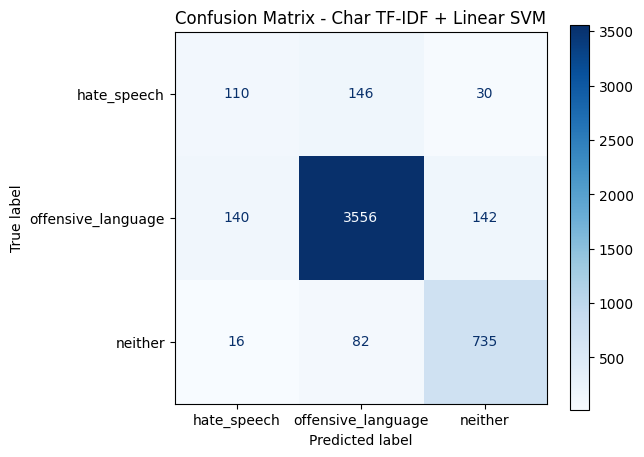

In [28]:
char_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=150000,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

char_svm_results = evaluate_model(
    char_svm_pipeline,
    X_train, y_train,
    X_val, y_val,
    model_name="Char TF-IDF + Linear SVM"
)

In [29]:
baseline_results_df = pd.DataFrame([
    {
        "Model": lr_results["model_name"],
        "Accuracy": lr_results["accuracy"],
        "Macro F1": lr_results["macro_f1"],
        "Weighted F1": lr_results["weighted_f1"]
    },
    {
        "Model": svm_results["model_name"],
        "Accuracy": svm_results["accuracy"],
        "Macro F1": svm_results["macro_f1"],
        "Weighted F1": svm_results["weighted_f1"]
    },
    {
        "Model": char_svm_results["model_name"],
        "Accuracy": char_svm_results["accuracy"],
        "Macro F1": char_svm_results["macro_f1"],
        "Weighted F1": char_svm_results["weighted_f1"]
    }
])

baseline_results_df = baseline_results_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
baseline_results_df

,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.896308,0.740577,0.894211
1,TF-IDF + Linear SVM,0.895300,0.734310,0.892861
2,Char TF-IDF + Linear SVM,0.887835,0.725489,0.887416


In [30]:
best_baseline_row = baseline_results_df.iloc[0]
print("Best baseline model:")
print(best_baseline_row)

Best baseline model:
Model          TF-IDF + Logistic Regression
Accuracy                           0.896308
Macro F1                           0.740577
Weighted F1                        0.894211
Name: 0, dtype: object


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import FeatureUnion


Combined Word + Char TF-IDF + Linear SVM
Accuracy     : 0.8985
Macro F1     : 0.7369
Weighted F1  : 0.8952

Classification Report:

                    precision    recall  f1-score   support

       hate_speech       0.48      0.36      0.41       286
offensive_language       0.94      0.94      0.94      3838
           neither       0.83      0.88      0.86       833

          accuracy                           0.90      4957
         macro avg       0.75      0.73      0.74      4957
      weighted avg       0.89      0.90      0.90      4957



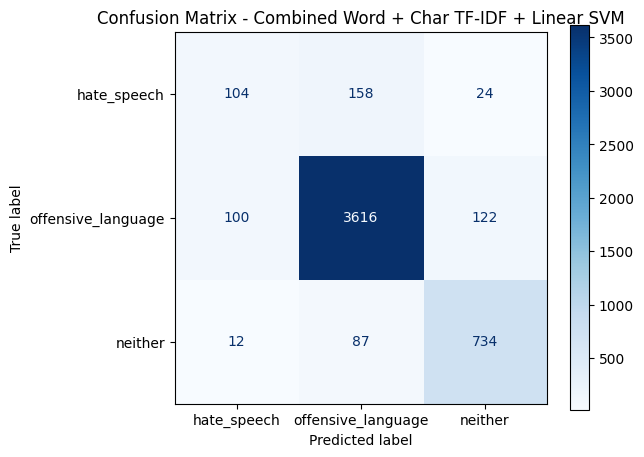

In [33]:
word_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

X_train_series = train_df["text"]
X_val_series = val_df["text"]

X_train_word = word_tfidf.fit_transform(X_train_series)
X_val_word = word_tfidf.transform(X_val_series)

X_train_char = char_tfidf.fit_transform(X_train_series)
X_val_char = char_tfidf.transform(X_val_series)

from scipy.sparse import hstack

X_train_combined = hstack([X_train_word, X_train_char])
X_val_combined = hstack([X_val_word, X_val_char])

combined_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

combined_svm.fit(X_train_combined, y_train)
combined_preds = combined_svm.predict(X_val_combined)

combined_acc = accuracy_score(y_val, combined_preds)
combined_macro_f1 = f1_score(y_val, combined_preds, average="macro")
combined_weighted_f1 = f1_score(y_val, combined_preds, average="weighted")

print("\n============================================================")
print("Combined Word + Char TF-IDF + Linear SVM")
print("============================================================")
print(f"Accuracy     : {combined_acc:.4f}")
print(f"Macro F1     : {combined_macro_f1:.4f}")
print(f"Weighted F1  : {combined_weighted_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_val, combined_preds, target_names=["hate_speech", "offensive_language", "neither"]))

cm = confusion_matrix(y_val, combined_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["hate_speech", "offensive_language", "neither"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Combined Word + Char TF-IDF + Linear SVM")
plt.show()

In [34]:
baseline_results_df = pd.concat([
    baseline_results_df,
    pd.DataFrame([{
        "Model": "Combined Word + Char TF-IDF + Linear SVM",
        "Accuracy": combined_acc,
        "Macro F1": combined_macro_f1,
        "Weighted F1": combined_weighted_f1
    }])
], ignore_index=True)

baseline_results_df = baseline_results_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
baseline_results_df

,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.896308,0.740577,0.894211
1,Combined Word + Char TF-IDF + Linear SVM,0.898527,0.736887,0.895211
2,TF-IDF + Linear SVM,0.895300,0.734310,0.892861
3,Char TF-IDF + Linear SVM,0.887835,0.725489,0.887416


In [36]:
baseline_results_df = pd.concat([
    baseline_results_df,
    pd.DataFrame([{
        "Model": "Combined Word + Char TF-IDF + Linear SVM",
        "Accuracy": combined_acc,
        "Macro F1": combined_macro_f1,
        "Weighted F1": combined_weighted_f1
    }])
], ignore_index=True)

baseline_results_df = baseline_results_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
baseline_results_df

,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.896308,0.740577,0.894211
1,Combined Word + Char TF-IDF + Linear SVM,0.898527,0.736887,0.895211
2,Combined Word + Char TF-IDF + Linear SVM,0.898527,0.736887,0.895211
3,TF-IDF + Linear SVM,0.895300,0.734310,0.892861
4,Char TF-IDF + Linear SVM,0.887835,0.725489,0.887416


In [37]:
!pip -q install transformers datasets accelerate

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [42]:
MODEL_NAME = "roberta-base"
MAX_LEN = 128
TRAIN_BATCH_SIZE = 16
VALID_BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_LABELS = 3

USE_FP16 = torch.cuda.is_available()

In [43]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.


In [44]:
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

        return item

In [45]:
train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = val_df["text"].tolist()
val_labels = val_df["label"].tolist()

train_dataset = ToxicDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer, MAX_LEN)

print("Train dataset size:", len(train_dataset))
print("Val dataset size  :", len(val_dataset))

Train dataset size: 19826
Val dataset size  : 4957


In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 1240
Val batches  : 155


In [47]:
class ToxicClassifier(nn.Module):
    def __init__(self, model_name, num_labels=3, dropout=0.3):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # RoBERTa has no pooler_output like BERT usually, so use CLS token
        last_hidden_state = outputs.last_hidden_state
        cls_embedding = last_hidden_state[:, 0, :]   # first token representation

        x = self.dropout(cls_embedding)
        logits = self.classifier(x)

        return logits

In [48]:
model = ToxicClassifier(MODEL_NAME, num_labels=NUM_LABELS, dropout=0.3)
model = model.to(device)

print("Model loaded successfully.")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


In [49]:
print("Class weights dict:", class_weights_dict)

class_weights_list = [class_weights_dict[i] for i in range(NUM_LABELS)]
class_weights_tensor = torch.tensor(class_weights_list, dtype=torch.float).to(device)

print("Class weights tensor:", class_weights_tensor)

Class weights dict: {0: 5.776806526806527, 1: 0.4304759423310752, 2: 1.9845845845845846}
Class weights tensor: tensor([5.7768, 0.4305, 1.9846], device='cuda:0')


In [50]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

print("Setup complete.")
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)

Setup complete.
Total training steps: 3720
Warmup steps: 372


In [52]:
from sklearn.metrics import precision_recall_fscore_support
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    precision, recall, f1_per_class, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1_per_class
    }
    return metrics

In [54]:
def train_one_epoch(model, data_loader, optimizer, scheduler, criterion, device, scaler):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_FP16):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(data_loader)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics

In [55]:
def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=USE_FP16):
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

            progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(data_loader)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics, all_labels, all_preds

In [56]:
best_val_macro_f1 = 0.0
history = []

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*70}")

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, scaler
    )

    val_loss, val_metrics, val_true, val_preds = validate_one_epoch(
        model, val_loader, criterion, device
    )

    epoch_result = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"]
    }
    history.append(epoch_result)

    print(f"Train Loss       : {train_loss:.4f}")
    print(f"Train Accuracy   : {train_metrics['accuracy']:.4f}")
    print(f"Train Macro F1   : {train_metrics['macro_f1']:.4f}")
    print(f"Train Weighted F1: {train_metrics['weighted_f1']:.4f}")

    print(f"Val Loss         : {val_loss:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Macro F1     : {val_metrics['macro_f1']:.4f}")
    print(f"Val Weighted F1  : {val_metrics['weighted_f1']:.4f}")

    print("\nPer-class Validation F1:")
    for idx, class_name in enumerate(["hate_speech", "offensive_language", "neither"]):
        print(f"{class_name:20s}: {val_metrics['f1_per_class'][idx]:.4f}")

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        torch.save(model.state_dict(), "best_roberta_toxic_model.pt")
        print("\nBest model saved.")

print(f"\nBest Validation Macro F1: {best_val_macro_f1:.4f}")


Epoch 1/3


Training:   0%|          | 0/1240 [00:00<?, ?it/s]

Validation:   0%|          | 0/155 [00:00<?, ?it/s]

Train Loss       : 0.6231
Train Accuracy   : 0.7807
Train Macro F1   : 0.6375
Train Weighted F1: 0.8089
Val Loss         : 0.4175
Val Accuracy     : 0.8378
Val Macro F1     : 0.7235
Val Weighted F1  : 0.8649

Per-class Validation F1:
hate_speech         : 0.3829
offensive_language  : 0.8947
neither             : 0.8930

Best model saved.

Epoch 2/3


Training:   0%|          | 0/1240 [00:00<?, ?it/s]

Validation:   0%|          | 0/155 [00:00<?, ?it/s]

Train Loss       : 0.4050
Train Accuracy   : 0.8548
Train Macro F1   : 0.7389
Train Weighted F1: 0.8752
Val Loss         : 0.4067
Val Accuracy     : 0.8838
Val Macro F1     : 0.7599
Val Weighted F1  : 0.8955

Per-class Validation F1:
hate_speech         : 0.4576
offensive_language  : 0.9286
neither             : 0.8935

Best model saved.

Epoch 3/3


Training:   0%|          | 0/1240 [00:00<?, ?it/s]

Validation:   0%|          | 0/155 [00:00<?, ?it/s]

Train Loss       : 0.3200
Train Accuracy   : 0.8730
Train Macro F1   : 0.7677
Train Weighted F1: 0.8910
Val Loss         : 0.3975
Val Accuracy     : 0.8519
Val Macro F1     : 0.7401
Val Weighted F1  : 0.8765

Per-class Validation F1:
hate_speech         : 0.4128
offensive_language  : 0.9055
neither             : 0.9022

Best Validation Macro F1: 0.7599


In [57]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,1,0.623126,0.780742,0.637465,0.808931,0.417455,0.837805,0.723543,0.864921
1,2,0.404972,0.854787,0.738897,0.875224,0.406741,0.883801,0.759877,0.895502
2,3,0.320044,0.872995,0.767688,0.890995,0.397462,0.851927,0.740137,0.876484


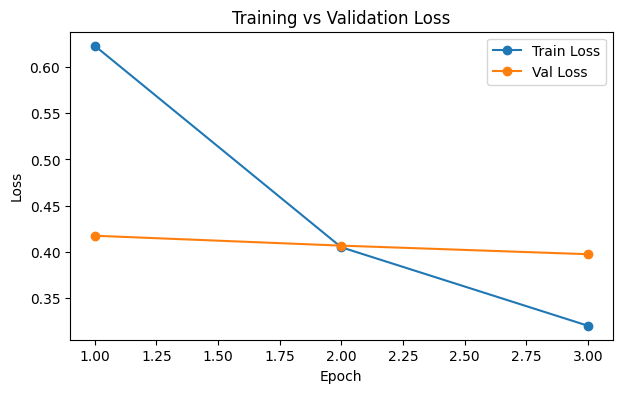

In [58]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

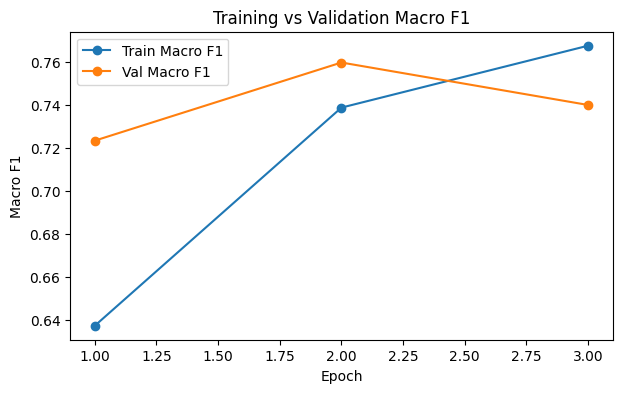

In [59]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Val Macro F1")
plt.title("Training vs Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.show()

In [60]:
best_model = ToxicClassifier(MODEL_NAME, num_labels=NUM_LABELS, dropout=0.3)
best_model.load_state_dict(torch.load("best_roberta_toxic_model.pt", map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("Best model loaded successfully.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best model loaded successfully.


In [61]:
final_val_loss, final_val_metrics, final_y_true, final_y_pred = validate_one_epoch(
    best_model, val_loader, criterion, device
)

print("\nFinal Validation Results (Best Saved Model)")
print("="*60)
print(f"Loss         : {final_val_loss:.4f}")
print(f"Accuracy     : {final_val_metrics['accuracy']:.4f}")
print(f"Macro F1     : {final_val_metrics['macro_f1']:.4f}")
print(f"Weighted F1  : {final_val_metrics['weighted_f1']:.4f}")

Validation:   0%|          | 0/155 [00:00<?, ?it/s]


Final Validation Results (Best Saved Model)
Loss         : 0.4067
Accuracy     : 0.8838
Macro F1     : 0.7599
Weighted F1  : 0.8955


In [62]:
print(classification_report(
    final_y_true,
    final_y_pred,
    target_names=["hate_speech", "offensive_language", "neither"]
))

                    precision    recall  f1-score   support

       hate_speech       0.35      0.65      0.46       286
offensive_language       0.97      0.89      0.93      3838
           neither       0.86      0.93      0.89       833

          accuracy                           0.88      4957
         macro avg       0.73      0.82      0.76      4957
      weighted avg       0.92      0.88      0.90      4957



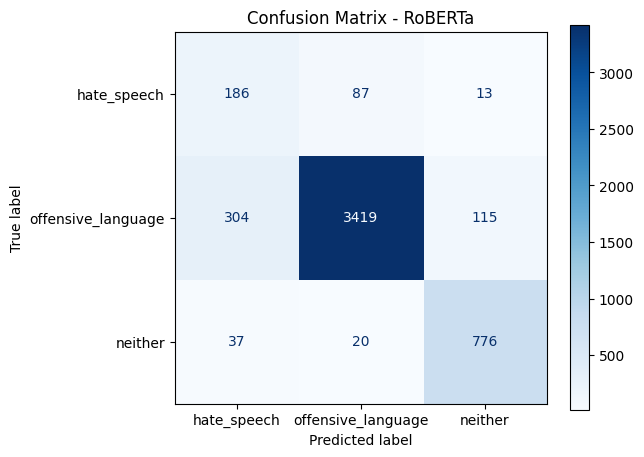

In [64]:
cm = confusion_matrix(final_y_true, final_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["hate_speech", "offensive_language", "neither"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - RoBERTa")
plt.show()

In [65]:
roberta_results = pd.DataFrame([{
    "Model": "RoBERTa-base + Weighted Loss",
    "Accuracy": final_val_metrics["accuracy"],
    "Macro F1": final_val_metrics["macro_f1"],
    "Weighted F1": final_val_metrics["weighted_f1"]
}])

all_results_df = pd.concat([baseline_results_df, roberta_results], ignore_index=True)
all_results_df = all_results_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
all_results_df

,Model,Accuracy,Macro F1,Weighted F1
0,RoBERTa-base + Weighted Loss,0.883801,0.759877,0.895502
1,TF-IDF + Logistic Regression,0.896308,0.740577,0.894211
2,Combined Word + Char TF-IDF + Linear SVM,0.898527,0.736887,0.895211
3,Combined Word + Char TF-IDF + Linear SVM,0.898527,0.736887,0.895211
4,TF-IDF + Linear SVM,0.895300,0.734310,0.892861
5,Char TF-IDF + Linear SVM,0.887835,0.725489,0.887416


In [66]:
history_df.to_csv("roberta_training_history.csv", index=False)
all_results_df.to_csv("all_model_results.csv", index=False)

print("Saved files:")
print("- best_roberta_toxic_model.pt")
print("- roberta_training_history.csv")
print("- all_model_results.csv")

Saved files:
- best_roberta_toxic_model.pt
- roberta_training_history.csv
- all_model_results.csv
